# Heart Failure Prediction

<a target="_blank" href="https://colab.research.google.com/github/LuisAngelMendozaVelasco/luisangelmendozavelasco.github.io/blob/master/_portfolio/Machine_Learning_Specialization/portfolio-3.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png">Run in Google Colab</a>

**Objective**: Train a XGBoost classifier to predict potential heart disease.

[XGBoost](https://en.wikipedia.org/wiki/XGBoost) is an open-source software library that provides a regularizing Gradient Boosting framework. It is an advanced implementation of Gradient Boosting, which is an ensemble technique using weak learners. XGBoost improves mistakes from previous trees by sequentially adding models to correct errors, making it a boosting algorithm. It is designed for efficiency, speed, and high performance, and it implements machine learning algorithms under the Gradient Boosting framework.

## Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier

sns.set_style("whitegrid")

## Download the dataset

In [2]:
%%bash

wget -nc --progress=bar:force:noscroll https://www.kaggle.com/api/v1/datasets/download/fedesoriano/heart-failure-prediction -O /tmp/heart-failure-prediction.zip
unzip -qn /tmp/heart-failure-prediction.zip -d /tmp/

File '/tmp/heart-failure-prediction.zip' already there; not retrieving.


## Load the dataset

In [3]:
df = pd.read_csv('/tmp/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Understand the dataset

Cardiovascular disease (CVD) is the number one cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Four out of five CVD deaths are due to heart attacks and strokes, and one-third of these deaths occur prematurely in people under 70 years of age. Heart failure is a common event caused by CVDs.

People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyperlipidaemia or already established disease) need early detection and management.

This dataset contains 11 features that can be used to predict potential heart disease:

- **Age**: age of the patient [years]
- **Sex**: sex of the patient [M: Male, F: Female]
- **ChestPainType**: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
- **RestingBP**: resting blood pressure [mm Hg]
- **Cholesterol**: serum cholesterol [mm/dl]
- **FastingBS**: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
- **RestingECG**: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
- **MaxHR**: maximum heart rate achieved [Numeric value between 60 and 202]
- **ExerciseAngina**: exercise-induced angina [Y: Yes, N: No]
- **Oldpeak**: oldpeak = ST [Numeric value measured in depression]
- **ST_Slope**: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
- **HeartDisease**: output class [1: Heart Disease, 0: Normal]

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


## Visualize the dataset

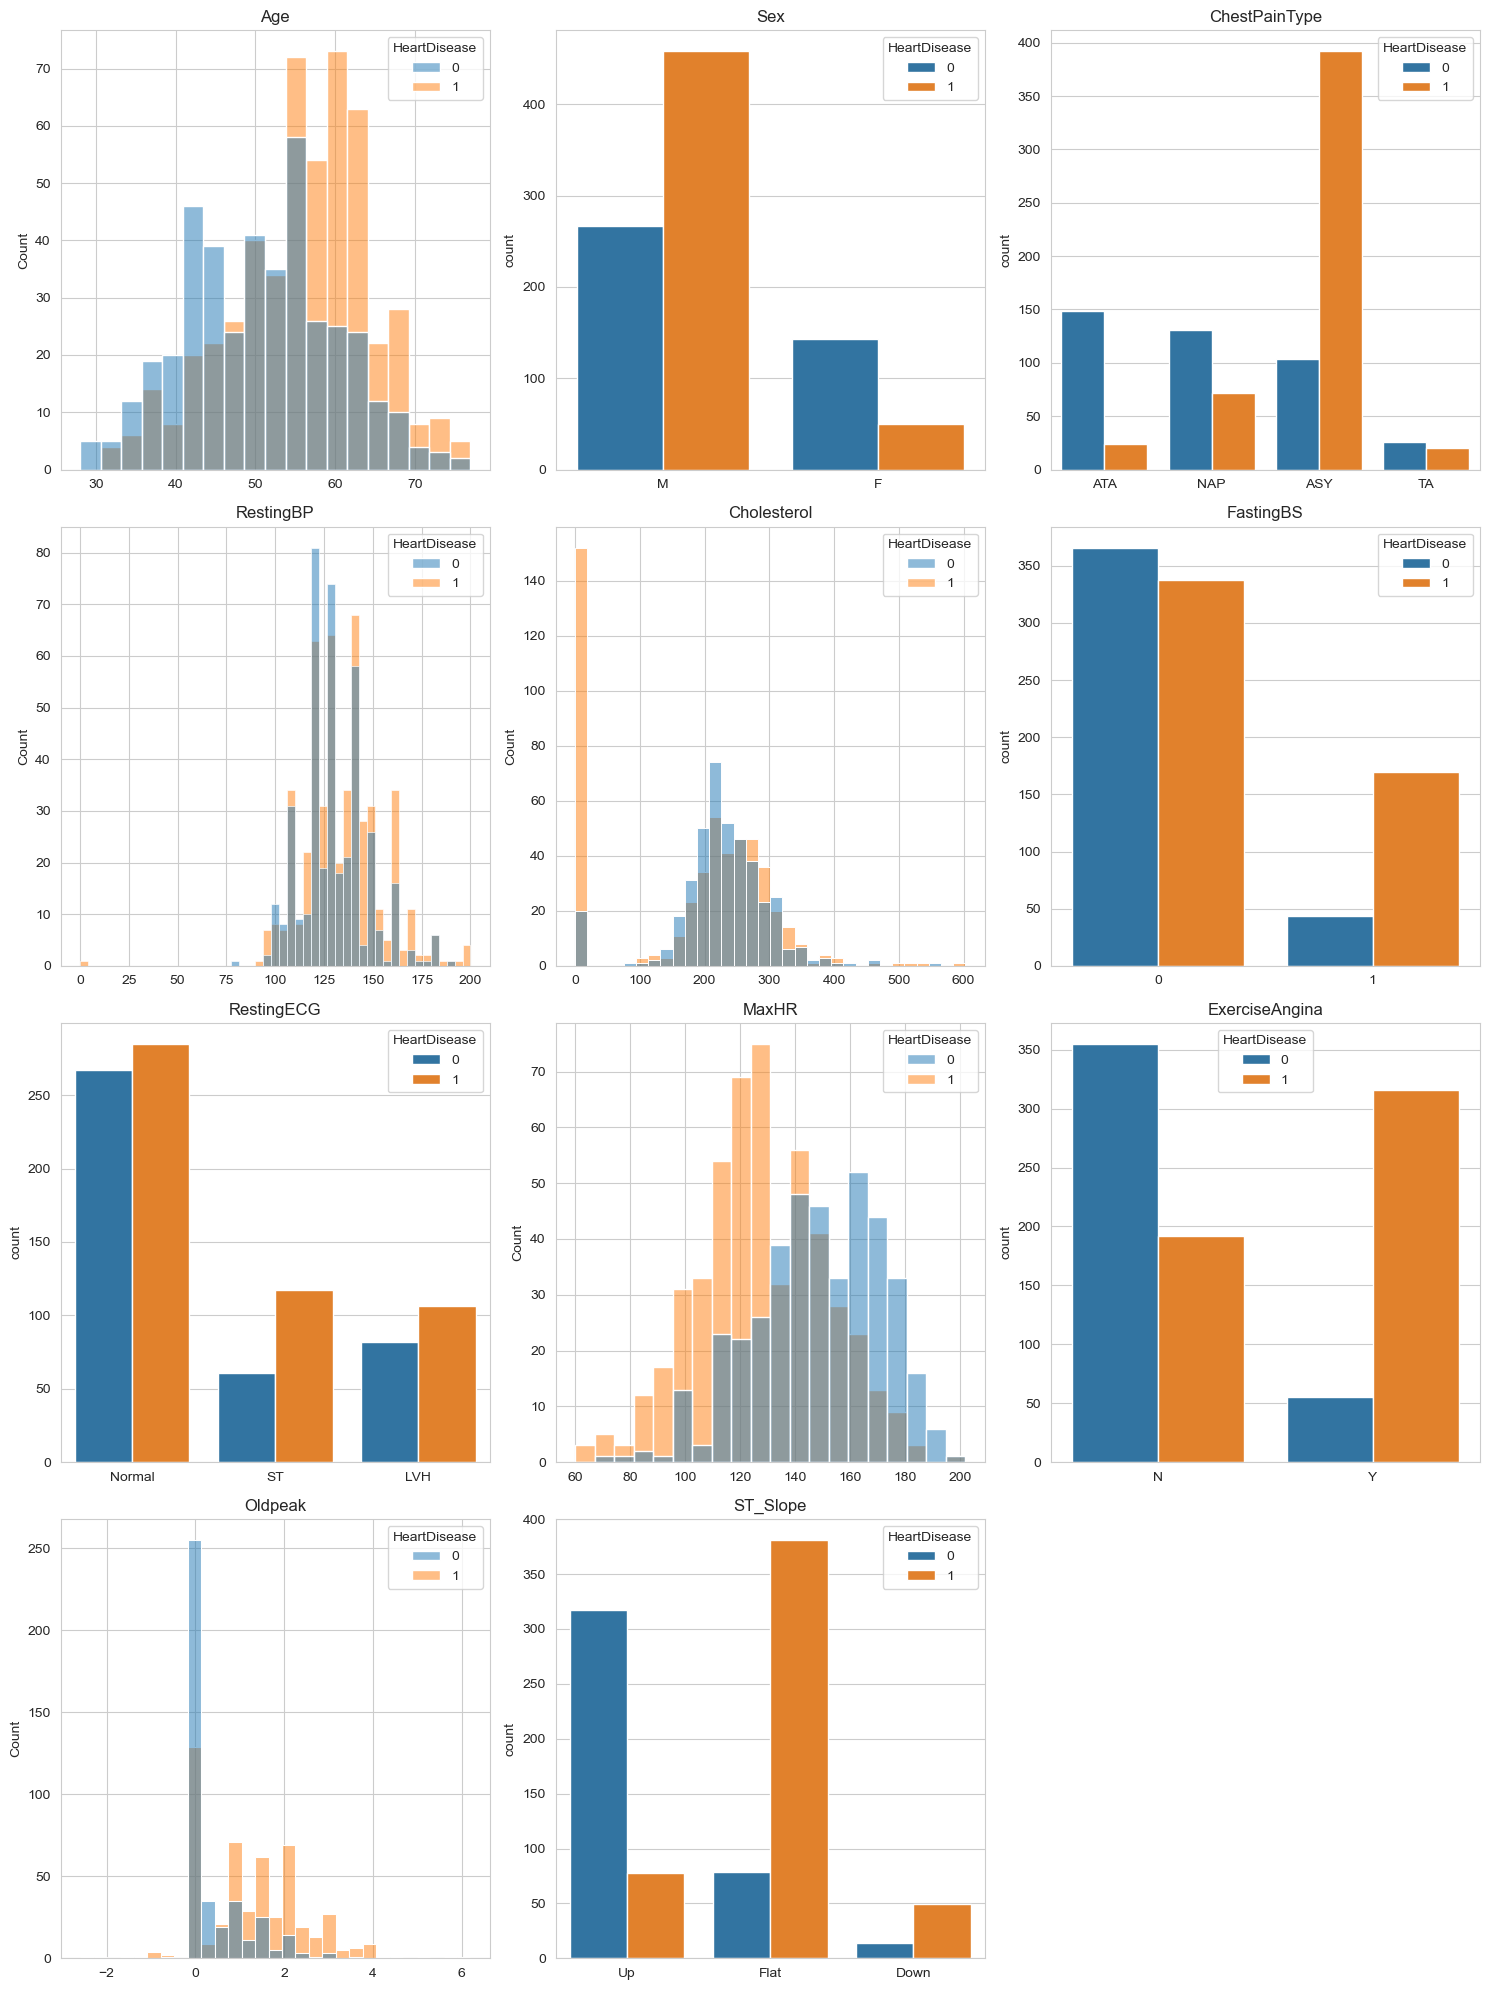

In [5]:
number_features = df.shape[1] - 1
grid_rows = int(np.ceil(number_features / 3))
fig, axs = plt.subplots(grid_rows, 3, figsize=(15, 5 * grid_rows))

for ax, feature in zip(axs.flatten(), df.columns[:-1]):
    if df[feature].dtype == 'O':
        sns.countplot(data=df, x=feature, hue="HeartDisease", ax=ax)
        ax.set_xlabel("")
        ax.set_title(feature)
    elif len(df[feature].unique()) <= 10:
        sns.countplot(data=df, x=feature, hue="HeartDisease", ax=ax)
        ax.set_xlabel("")
        ax.set_title(feature)
    else:
        sns.histplot(data=df, x=feature, hue="HeartDisease", ax=ax)
        ax.set_xlabel("")
        ax.set_title(feature)

for ax in axs.flatten()[number_features:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Visualize the class distribution

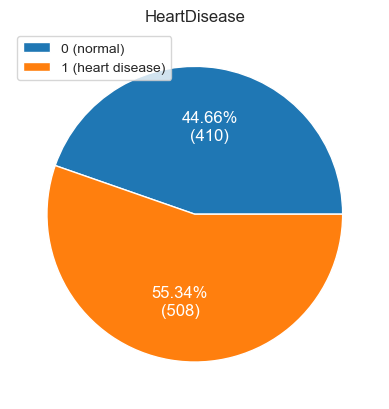

In [6]:
target_feature = df.columns[-1]
labels, sizes = np.unique(df[target_feature], return_counts=True)

fig, ax = plt.subplots()
ax.pie(sizes, textprops={'color': "w", 'fontsize': '12'}, autopct=lambda pct: "{:.2f}%\n({:d})".format(pct, round(pct/100 * sum(sizes))))
ax.legend([str(i) + " (normal)" if i == 0 else str(i) + " (heart disease)" for i in labels])
ax.set_title(target_feature)
plt.show()

## Preprocess the dataset

In [7]:
categorical_features = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(data=df, columns=categorical_features, drop_first=True)
df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


## Split the dataset into train and test subsets

In [8]:
X = df.drop(columns=[target_feature])
y = df[target_feature]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (688, 15)
X_test shape: (230, 15)


## Train a XGBoost classifier

In [9]:
xgb_classifier = XGBClassifier(n_estimators=500, learning_rate=0.1, max_depth=5)
xgb_classifier.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Evaluate the XGBoost classifier

              precision    recall  f1-score   support

           0     0.8605    0.8043    0.8315        92
           1     0.8750    0.9130    0.8936       138

    accuracy                         0.8696       230
   macro avg     0.8677    0.8587    0.8625       230
weighted avg     0.8692    0.8696    0.8688       230



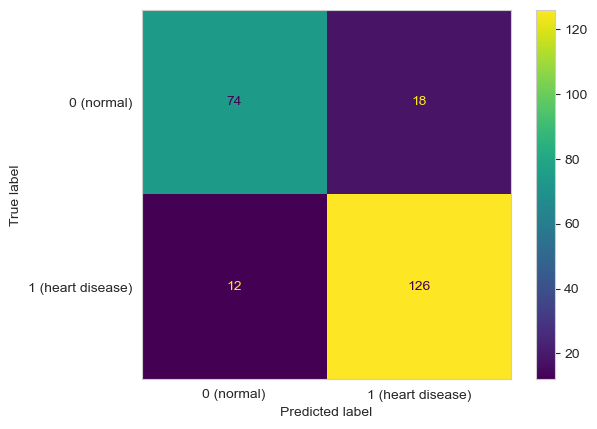

In [10]:
y_pred = xgb_classifier.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["0 (normal)", "1 (heart disease)"])
plt.grid(False)
plt.show()